# 🧭 Notebook 01 — Exploratory Data Analysis (EDA)

*Author: Dr. Taiwo A. Famuyiwa*  
*Date: October 2025*

> Goal: Understand the UCI Heart Disease dataset (schema, distributions, missingness, outliers, target balance, early signal), and write down decisions for preprocessing & modeling.

In [ ]:
# (Colab only) Mount Drive and set project root
IN_COLAB = "google.colab" in str(get_ipython())
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    %cd /content/drive/MyDrive/Dr. Taiwo famuyiwa - Data Science & Biostatistics Portfolio/Machine Learning Projects/Heart-Disease-Prediction

# Ensure we can import from src/
import os, sys
sys.path.append(os.getcwd())

# Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set(context="notebook", style="whitegrid")

# Project helpers
from src.data import load_data

Mounted at /content/drive
/content/drive/MyDrive/Dr. Taiwo famuyiwa - Data Science & Biostatistics Portfolio/Machine Learning Projects/Heart-Disease-Prediction


In [ ]:
df = load_data()
print(df.shape)
df.head()

✅ Dataset loaded and verified successfully!
(304, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,39.0,0.0,3.0,94.0,199.0,0.0,0.0,179.0,0.0,0.0,1.0,0.0,3.0,0
1,39.0,1.0,3.0,140.0,321.0,0.0,2.0,182.0,0.0,0.0,1.0,0.0,3.0,0
2,52.0,0.0,3.0,136.0,196.0,0.0,2.0,169.0,0.0,0.1,2.0,0.0,3.0,0
3,50.0,0.0,4.0,110.0,254.0,0.0,2.0,159.0,0.0,0.0,1.0,0.0,3.0,0
4,60.0,0.0,4.0,158.0,305.0,0.0,2.0,161.0,0.0,0.0,1.0,0.0,3.0,1


In [ ]:
## Data Dictionary (reference cell)

data_dict = {
    "age": "Age in years",
    "sex": "1=male, 0=female",
    "cp": "Chest pain type (0–3)",
    "trestbps": "Resting blood pressure (mm Hg)",
    "chol": "Serum cholesterol (mg/dl)",
    "fbs": "Fasting blood sugar >120 mg/dl (1=true, 0=false)",
    "restecg": "Resting ECG results (0–2)",
    "thalach": "Max heart rate achieved",
    "exang": "Exercise induced angina (1=yes, 0=no)",
    "oldpeak": "ST depression induced by exercise",
    "slope": "Slope of the peak exercise ST segment",
    "ca": "Number of major vessels (0–3) colored by fluoroscopy",
    "thal": "Thalassemia (0=null,1=fixed,2=normal,3=reversible)",
    "target": "1=disease, 0=no disease"
}

pd.Series(data_dict, name="Description")

,Description
age,Age in years
sex,"1=male, 0=female"
cp,Chest pain type (0–3)
trestbps,Resting blood pressure (mm Hg)
chol,Serum cholesterol (mg/dl)
fbs,"Fasting blood sugar >120 mg/dl (1=true, 0=false)"
restecg,Resting ECG results (0–2)
thalach,Max heart rate achieved
exang,"Exercise induced angina (1=yes, 0=no)"
oldpeak,ST depression induced by exercise


In [ ]:
## df.info()
display(df.describe(include="all").T)


# Missingness overview
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

,count,mean,std,min,25%,50%,75%,max
age,304.0,54.259868,9.548637,0.0,47.75,55.5,61.0,77.0
sex,304.0,0.680921,0.466888,0.0,0.00,1.0,1.0,1.0
cp,304.0,3.154605,0.960840,1.0,3.00,3.0,4.0,4.0
trestbps,304.0,131.266447,19.057964,3.0,120.00,130.0,140.0,200.0
chol,304.0,245.894737,53.532712,4.0,211.00,240.5,275.0,564.0
fbs,304.0,0.164474,0.451533,0.0,0.00,0.0,0.0,5.0
restecg,304.0,1.006579,1.034052,0.0,0.00,1.0,2.0,6.0
thalach,304.0,149.138158,24.257706,7.0,133.00,152.5,166.0,202.0
exang,304.0,0.351974,0.643164,0.0,0.00,0.0,1.0,8.0
oldpeak,304.0,1.065789,1.245830,0.0,0.00,0.8,1.6,9.0


,0


## Target balance

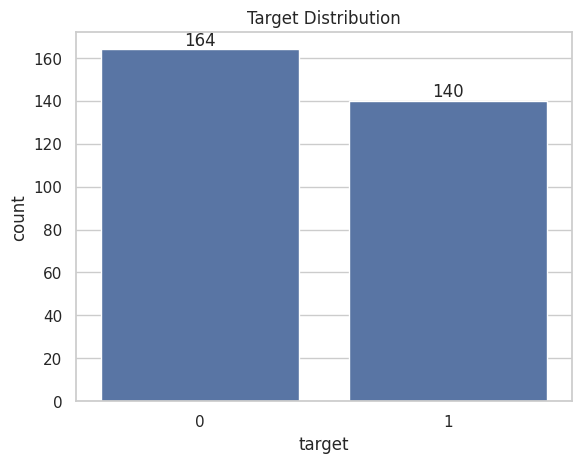

,proportion
target,
0,0.539474
1,0.460526


In [ ]:
ax = sns.countplot(x="target", data=df)
ax.bar_label(ax.containers[0])
plt.title("Target Distribution")
plt.show()

df["target"].value_counts(normalize=True).rename("proportion")


## Numerical distribution & outliers

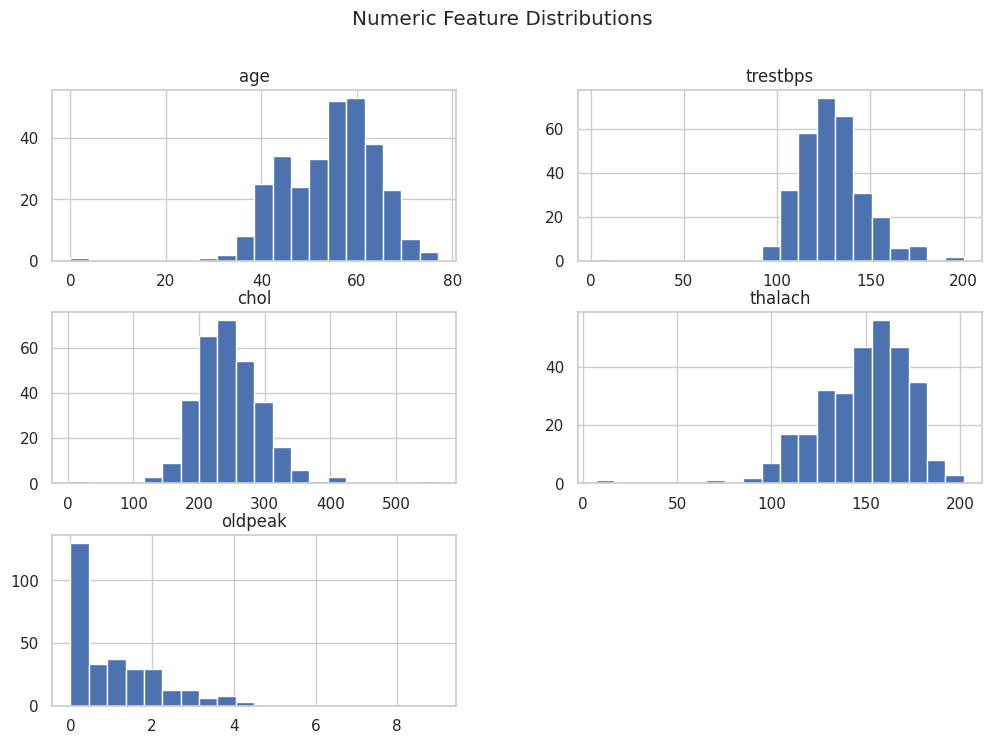

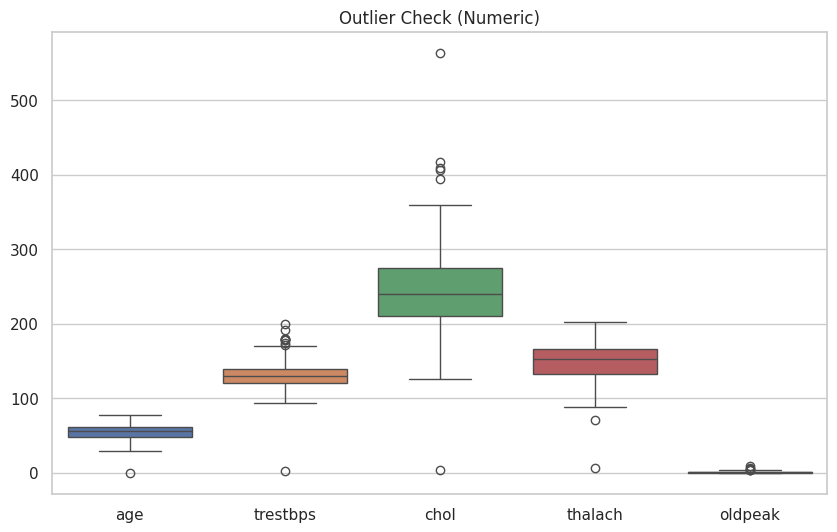

In [ ]:
num_cols = ["age","trestbps","chol","thalach","oldpeak"]
df[num_cols].hist(figsize=(12,8), bins=20)
plt.suptitle("Numeric Feature Distributions")
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(data=df[num_cols])
plt.title("Outlier Check (Numeric)")
plt.show()


## Categorical Levels (Sanity checks)


In [ ]:
cat_cols = ["sex","cp","fbs","restecg","exang","slope","ca","thal"]
for c in cat_cols:
    ct = df[c].value_counts(dropna=False).sort_index()
    display(pd.DataFrame({c: ct}))


,sex
sex,
0.0,97
1.0,207


,cp
cp,
1.0,23
2.0,51
3.0,86
4.0,144


,fbs
fbs,
0.0,258
1.0,45
5.0,1


,restecg
restecg,
0.0,151
1.0,4
2.0,148
6.0,1


,exang
exang,
0.0,204
1.0,99
8.0,1


,slope
slope,
1.0,142
2.0,140
3.0,21
10.0,1


,ca
ca,
0.0,180
1.0,65
2.0,38
3.0,20
11.0,1


,thal
thal,
3.0,168
6.0,18
7.0,117
12.0,1


## Correlation matrix (Pearson on numeric + target)

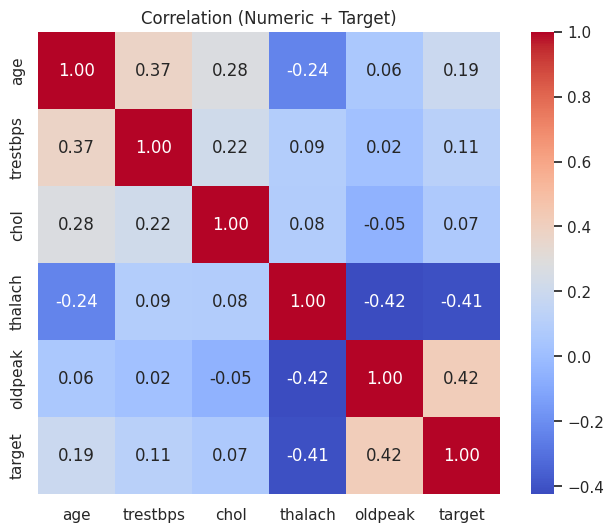

In [ ]:
corr = df[num_cols + ["target"]].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation (Numeric + Target)")
plt.show()


## Feature vs target

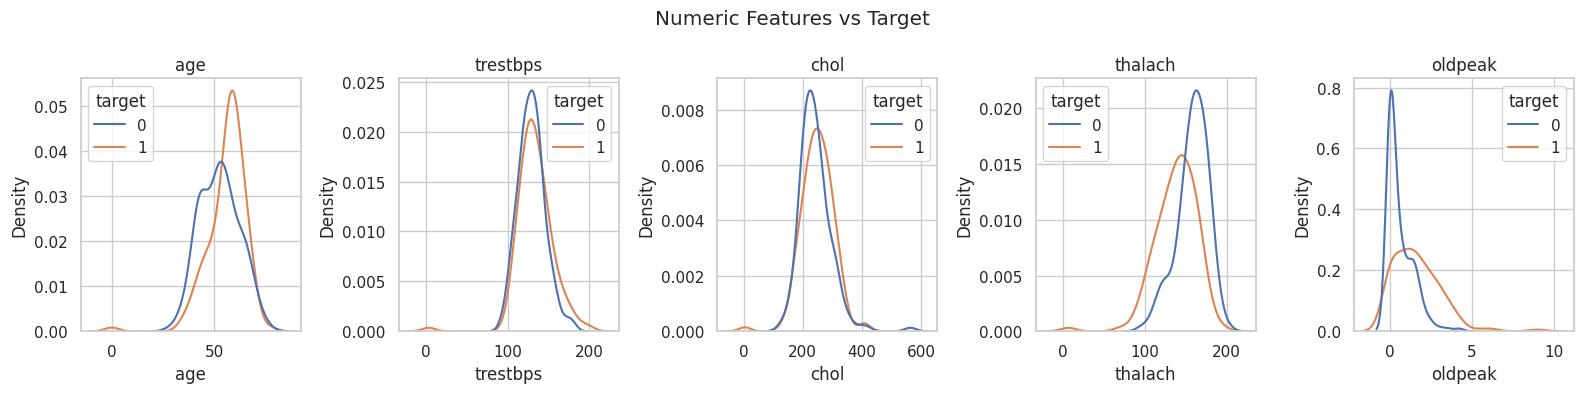

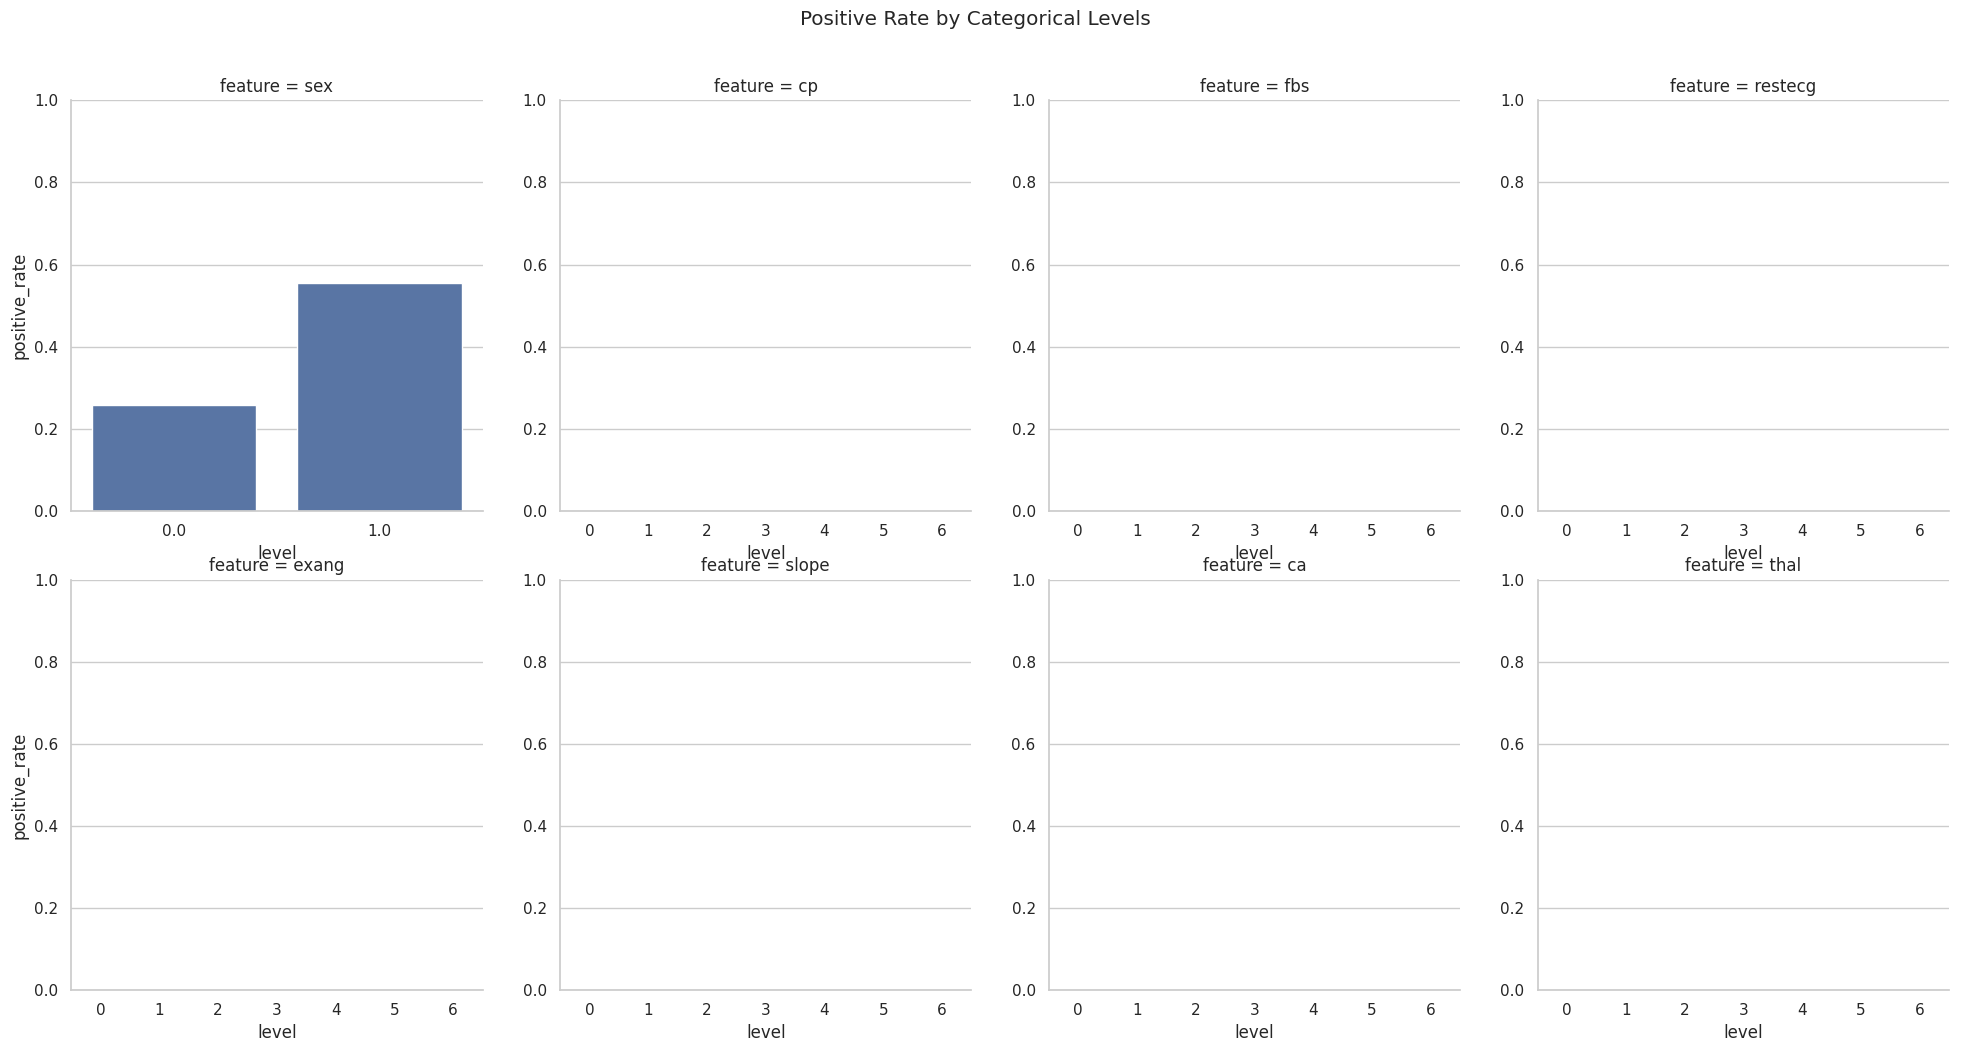

In [ ]:
# Numeric vs target
fig, axes = plt.subplots(1, len(num_cols), figsize=(16,4))
for ax, col in zip(axes, num_cols):
    sns.kdeplot(data=df, x=col, hue="target", ax=ax, common_norm=False)
    ax.set_title(col)
plt.suptitle("Numeric Features vs Target")
plt.tight_layout()
plt.show()

# Categorical vs target (rate plots)
rates = []
for c in cat_cols:
    tab = df.groupby(c)["target"].mean().rename("positive_rate").reset_index()
    tab["feature"] = c
    rates.append(tab)
rate_df = pd.concat(rates, ignore_index=True)

g = sns.catplot(
    data=rate_df, x="index" if "index" in rate_df.columns else cat_cols[0],
    y="positive_rate", col="feature", col_wrap=4, kind="bar", sharex=False, sharey=False
)
for ax in g.axes.flat:
    ax.set_xlabel("level")
    ax.set_ylim(0, 1)
plt.suptitle("Positive Rate by Categorical Levels", y=1.05)
plt.show()


## Pairwise relationships (optional, subset to avoid clutter)


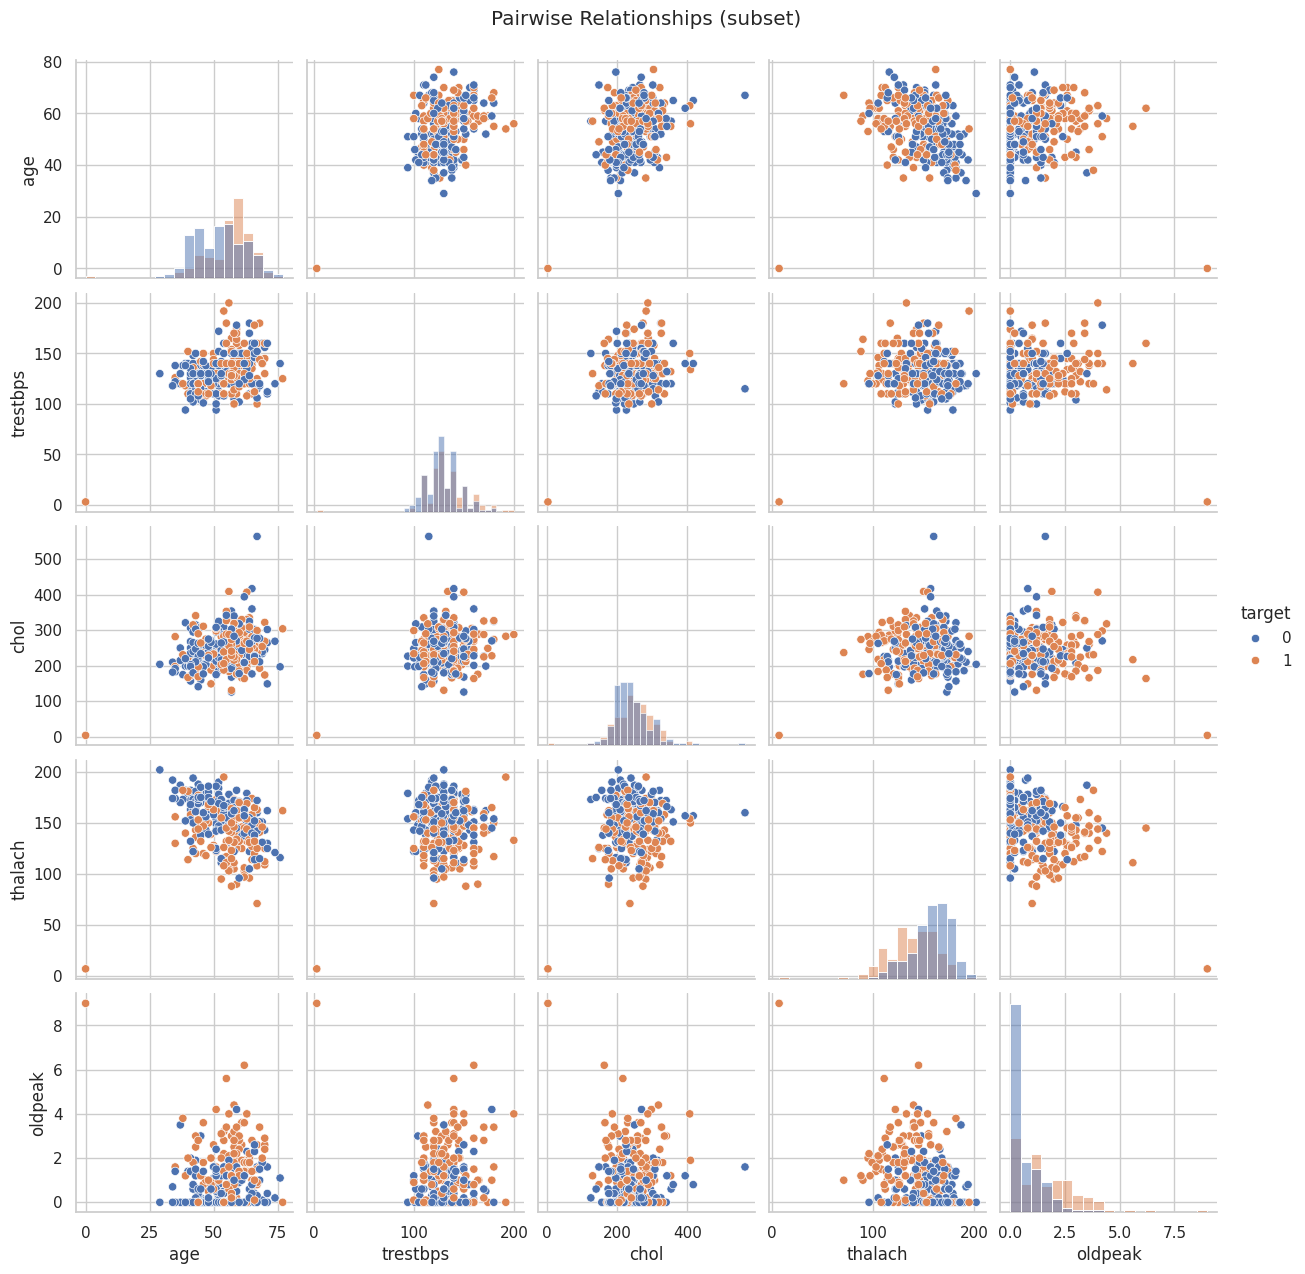

In [ ]:
subset = ["age","trestbps","chol","thalach","oldpeak","target"]
sns.pairplot(df[subset], hue="target", diag_kind="hist")
plt.suptitle("Pairwise Relationships (subset)", y=1.02)
plt.show()


## Pairwise  relationships (optional, subset to avoid clustter)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

X = df.drop(columns=["target"])
y = df["target"]

pre = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline(steps=[
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ]
)

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

pipe = Pipeline([("pre", pre), ("clf", LogisticRegression(max_iter=200))])
pipe.fit(X_tr, y_tr)
proba = pipe.predict_proba(X_te)[:, 1]
auc = roc_auc_score(y_te, proba)
print(f"Quick AUC (holdout): {auc:.3f}")


Quick AUC (holdout): 0.881


## PCA visualization

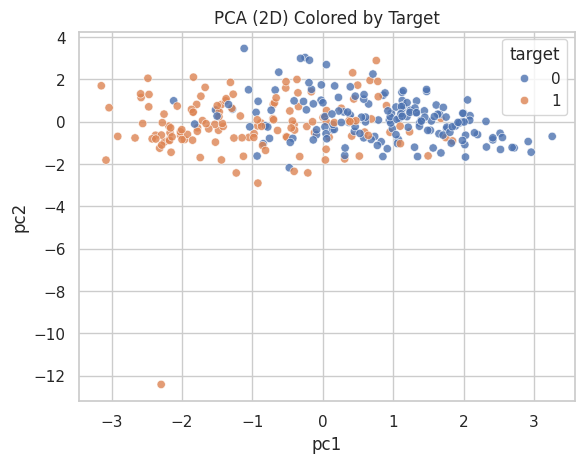

In [ ]:
from sklearn.decomposition import PCA

# Use the same preprocessor to avoid data leakage illusions
Z = pre.fit_transform(X)
pca = PCA(n_components=2, random_state=42)
Z2 = pca.fit_transform(Z.toarray() if hasattr(Z, "toarray") else Z)

viz = pd.DataFrame({"pc1": Z2[:,0], "pc2": Z2[:,1], "target": y})
sns.scatterplot(data=viz, x="pc1", y="pc2", hue="target", alpha=0.8)
plt.title("PCA (2D) Colored by Target")
plt.show()


## EDA notes & decisions

### Decisions from EDA
- **Missingness:** (e.g.) No missing values detected → proceed with simple imputers as safety.
- **Outliers:** (e.g.) `chol` has a few high values; choose to keep and rely on tree models’ robustness; also standardize for linear models.
- **Categoricals:** Treat `cp`, `slope`, `thal`, `restecg`, `ca`, `sex`, `fbs`, `exang` as categorical.
- **Target balance:** Slightly imbalanced but acceptable; consider class_weight="balanced".
- **Preprocessing plan:** median impute + standardize numerics; impute + one-hot encode categoricals.
- **Metric:** Use ROC-AUC as primary, also PR-AUC for class imbalance insights.

Next → implement preprocessing & splits in **Notebook 02** and `src/data.py`.
